# 🚗 Araç Fiyat Tahmini - Regresyon Analizi (Car Market Analytics Regression)

## Proje Amacı
Bu projede, çeşitli teknik özellikleri (motor hacmi, beygir gücü, kilometre, yakıt tipi, vites tipi vb.) bulunan ikinci el araçların satış fiyatını (**Selling_Price**) tahmin eden bir regresyon modeli geliştirilmiştir. Amaç, ikinci el araç piyasasında fiyatlandırma kararlarına veri odaklı destek sağlayabilecek bir makine öğrenmesi çözümü ortaya koymaktır.

## Veri Seti
Veri seti; araç markası, modeli, üretim yılı, yakıt tipi, vites tipi, motor hacmi, kilometre, beygir gücü, tork, sahip sayısı, kaza geçmişi, satış lokasyonu gibi değişkenler içermektedir. Hedef değişken **Selling_Price** (satış fiyatı) sürekli (numerik) bir değişkendir.

## İzlenen Yöntem
1. **Keşifsel Veri Analizi (EDA):** Eksik değer kontrolü, kategorik/numerik değişken ayrımı, korelasyon analizi ve çeşitli görselleştirmelerle veri setinin genel yapısı incelenmiştir.
2. **Ön İşleme (Preprocessing):** Eksik değerler için imputation, kategorik değişkenler için One-Hot Encoding, sayısal değişkenler için Standardizasyon uygulanmış; tüm bu adımlar `ColumnTransformer` ve `Pipeline` yapısıyla otomatikleştirilmiştir.
3. **Modelleme:** Linear Regression, Ridge, Lasso, ElasticNet, SVR, KNN, Decision Tree, Random Forest, AdaBoost, Gradient Boosting, XGBoost ve LightGBM olmak üzere 12 farklı regresyon modeli denenmiş ve performansları karşılaştırılmıştır.
4. **Hiperparametre Optimizasyonu:** En başarılı model olan XGBoost üzerinde `GridSearchCV` ile hiperparametre optimizasyonu yapılmıştır.
5. **Model Yorumlama:** XGBoost'un feature importance (değişken önem düzeyi) çıktıları incelenerek, fiyatı en çok etkileyen değişkenler belirlenmiştir.

## Kullanılan Kütüphaneler
`pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `xgboost`, `lightgbm`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("4-)automobile_dataset.csv")
df.head()

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
0,Mercedes-Benz,GLE,2024,Petrol,Automatic,2.3,100,186.0,196.0,1,0.0,NaN,Silver,SUV,AWD,30.0,IL,64140
1,Hyundai,Tucson,2008,Petrol,Automatic,2.3,387035,189.0,190.0,4,0.0,NaN,Blue,SUV,FWD,35.0,FL,500
2,Volkswagen,Golf,2021,Hybrid,NaN,1.9,46054,158.0,153.0,1,0.0,Partial Service,Gray,Hatchback,AWD,43.0,NY,16429
3,Chevrolet,Tahoe,2005,Petrol,NaN,2.2,141302,169.0,165.0,5,1.0,No Service,Blue,SUV,AWD,NaN,FL,2199
4,Toyota,Camry,2022,Petrol,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Make              5500 non-null   object 
 1   Model             5500 non-null   object 
 2   Year              5500 non-null   int64  
 3   Fuel_Type         5500 non-null   object 
 4   Transmission      4673 non-null   object 
 5   Engine_Size       4656 non-null   float64
 6   Mileage           5500 non-null   int64  
 7   Horsepower        4700 non-null   float64
 8   Torque            4701 non-null   float64
 9   Owners            5500 non-null   int64  
 10  Accident_History  4688 non-null   float64
 11  Service_History   4645 non-null   object 
 12  Color             4697 non-null   object 
 13  Body_Type         5500 non-null   object 
 14  Drivetrain        5500 non-null   object 
 15  Fuel_Efficiency   4706 non-null   float64
 16  Location          4718 non-null   object 


In [4]:
df.isnull().sum()

Make                  0
Model                 0
Year                  0
Fuel_Type             0
Transmission        827
Engine_Size         844
Mileage               0
Horsepower          800
Torque              799
Owners                0
Accident_History    812
Service_History     855
Color               803
Body_Type             0
Drivetrain            0
Fuel_Efficiency     794
Location            782
Selling_Price         0
dtype: int64

In [5]:
null_cat_col= ["Transmission", "Service_History", "Location", "Coloe"]
null_num_col= ["Engine_Size", "Horsepower", "Torque", "Accident_History", "Fuel_Efficiency"]

In [6]:
cat_col= df.select_dtypes(include=["object"]).columns.tolist()
cat_col

['Make',
 'Model',
 'Fuel_Type',
 'Transmission',
 'Service_History',
 'Color',
 'Body_Type',
 'Drivetrain',
 'Location']

In [7]:
num_col= df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_col

['Year',
 'Engine_Size',
 'Mileage',
 'Horsepower',
 'Torque',
 'Owners',
 'Accident_History',
 'Fuel_Efficiency',
 'Selling_Price']

In [8]:
num_col.remove("Selling_Price")
num_col

['Year',
 'Engine_Size',
 'Mileage',
 'Horsepower',
 'Torque',
 'Owners',
 'Accident_History',
 'Fuel_Efficiency']

In [9]:
for i in cat_col:
    print(df[i].value_counts())

Make
Hyundai          579
Ford             579
Volkswagen       569
Chevrolet        556
Honda            553
Nissan           542
Mercedes-Benz    541
Toyota           531
Audi             528
BMW              522
Name: count, dtype: int64
Model
GLE           166
Elantra       163
Passat        156
Malibu        156
Civic         156
Explorer      153
Silverado     152
Santa Fe      150
Escape        150
A4            149
Mustang       149
Tiguan        148
Sentra        146
5 Series      142
Rogue         140
RAV4          140
Q7            138
Accord        137
Atlas         136
Sonata        135
Camry         135
3 Series      134
CR-V          134
GLC           133
Corolla       133
X5            132
E-Class       132
Tucson        131
Pathfinder    129
A6            129
Golf          129
Equinox       128
Altima        127
F-150         127
Pilot         126
Highlander    123
Tahoe         120
X3            114
Q5            112
C-Class       110
Name: count, dtype: int64
Fuel_Ty

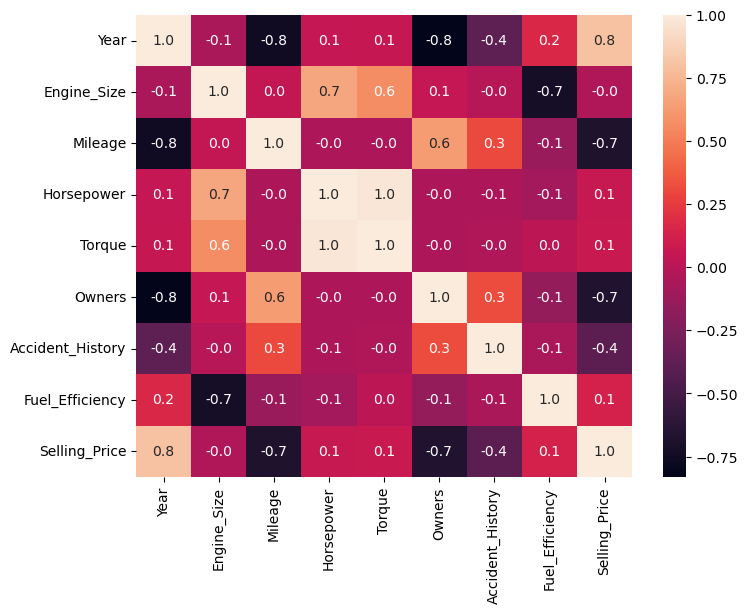

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".1f")
plt.show()

Horsepower ile Tork neredeyse aynı bilgileri taşıyor (multicollinearity) bundan dolayı lineer makine öğrenimi algoritmalarından 2 sütundan birisi 
drop edilerek sonuçlara tekrar bakılabilir. Ağaç bazlı modellerde ise bu bir sorun değildir.

In [11]:
df.corr(numeric_only=True)["Selling_Price"].sort_values(ascending=False)

Selling_Price       1.000000
Year                0.804933
Fuel_Efficiency     0.128593
Torque              0.075116
Horsepower          0.064324
Engine_Size        -0.030062
Accident_History   -0.391484
Owners             -0.669046
Mileage            -0.682883
Name: Selling_Price, dtype: float64

In [12]:
df.corr(numeric_only=True)

,Year,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Fuel_Efficiency,Selling_Price
Year,1.000000,-0.061126,-0.754184,0.052972,0.056140,-0.830702,-0.383245,0.163573,0.804933
Engine_Size,-0.061126,1.000000,0.041886,0.672033,0.569936,0.051901,-0.001325,-0.725594,-0.030062
Mileage,-0.754184,0.041886,1.000000,-0.045061,-0.045893,0.628654,0.302310,-0.127446,-0.682883
Horsepower,0.052972,0.672033,-0.045061,1.000000,0.976638,-0.048265,-0.051076,-0.089927,0.064324
Torque,0.056140,0.569936,-0.045893,0.976638,1.000000,-0.046096,-0.036168,0.023809,0.075116
Owners,-0.830702,0.051901,0.628654,-0.048265,-0.046096,1.000000,0.316544,-0.147069,-0.669046
Accident_History,-0.383245,-0.001325,0.302310,-0.051076,-0.036168,0.316544,1.000000,-0.057804,-0.391484
Fuel_Efficiency,0.163573,-0.725594,-0.127446,-0.089927,0.023809,-0.147069,-0.057804,1.000000,0.128593
Selling_Price,0.804933,-0.030062,-0.682883,0.064324,0.075116,-0.669046,-0.391484,0.128593,1.000000


In [13]:
#horsepower <-> torque ilişkisi yüksek

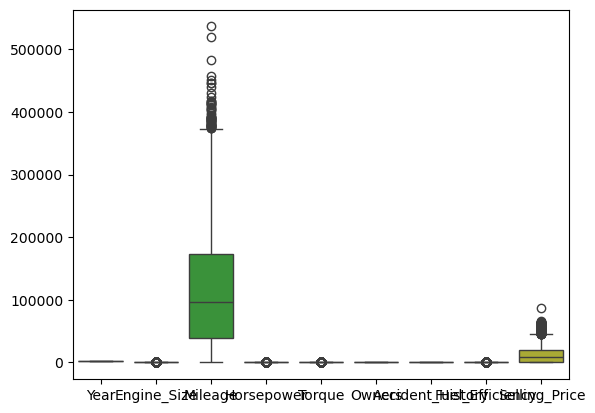

In [14]:
sns.boxplot(df)
plt.show()

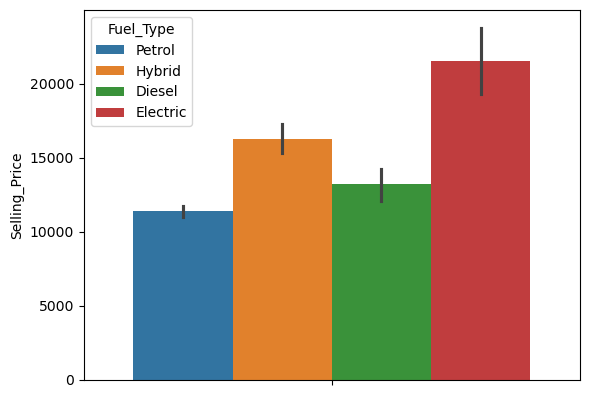

In [15]:
sns.barplot(y= df["Selling_Price"], hue= df["Fuel_Type"], fill=True)
plt.show()

Yakıt tiplerinin satış fiyatına olan etkisi arasında ciddi bir ilişki var. Bu nedenle model öğrenimi için önemli bir feature olabilir. 

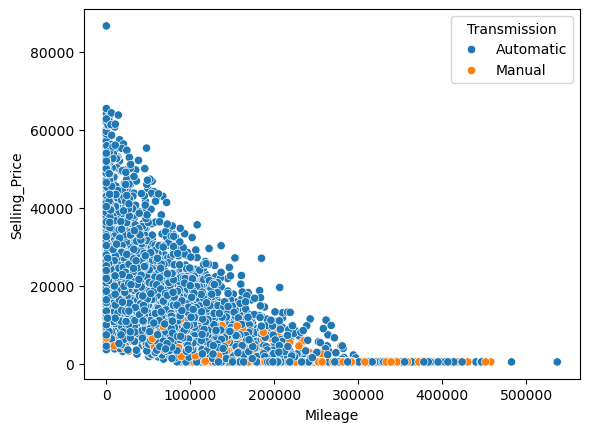

In [16]:
sns.scatterplot(x=df["Mileage"], y=df["Selling_Price"], hue= df["Transmission"])
plt.show()

Mileaage (kilometre) arttıkça beklendiği üzere satış fiyatı düşüyor ve aynı kilometeredeki araçlarda transmission türüne göre net bir etkisi gözlemlenmiyor.

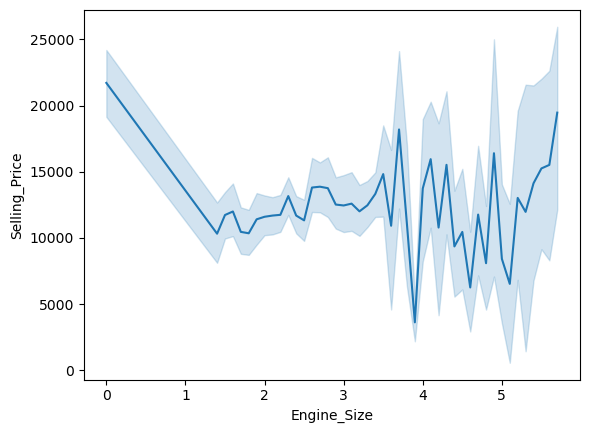

In [17]:
sns.lineplot(x=df["Engine_Size"], y=df["Selling_Price"])
plt.show()

C:\Users\tolga\AppData\Local\Temp\ipykernel_15112\408869069.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Color"], palette="Set2")


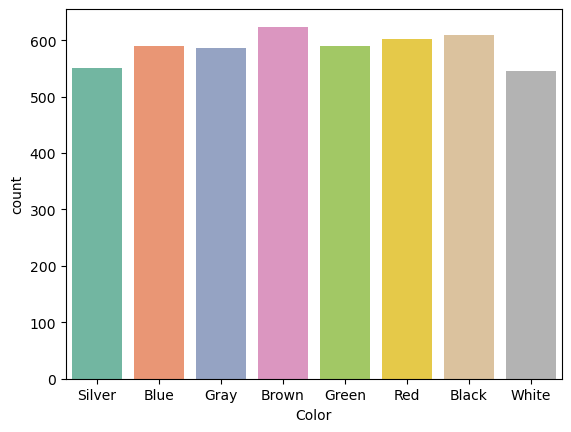

In [18]:
sns.countplot(x=df["Color"], palette="Set2")
plt.show()

C:\Users\tolga\AppData\Local\Temp\ipykernel_15112\2263980727.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["Drivetrain"], y=df["Selling_Price"], palette="Set2")


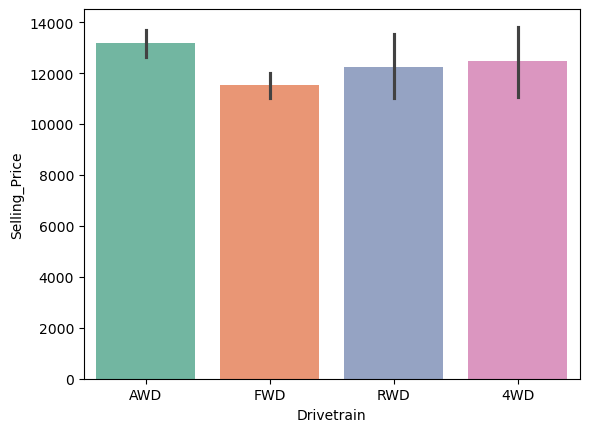

In [19]:
sns.barplot(x=df["Drivetrain"], y=df["Selling_Price"], palette="Set2")
plt.show()

Çekiş türlerinin satış fiyatında farklar gözlemlense de çok net bir ayrım yoktur

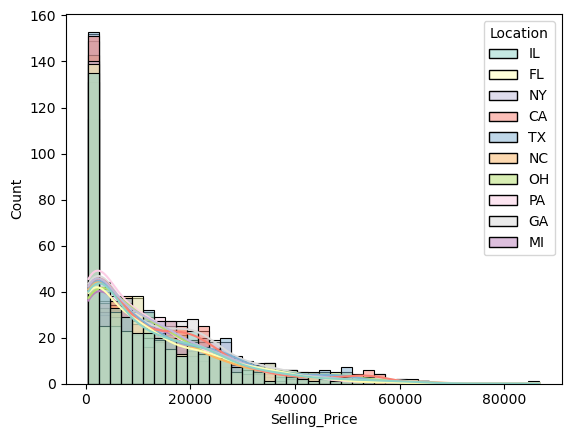

In [20]:
sns.histplot(x=df["Selling_Price"], hue=df["Location"], palette="Set3", kde=True)
plt.show()

Araçların satıldıkları ülkelerdeki fiyatlar farklılık gösterse de çok net bir ayrım yoktur

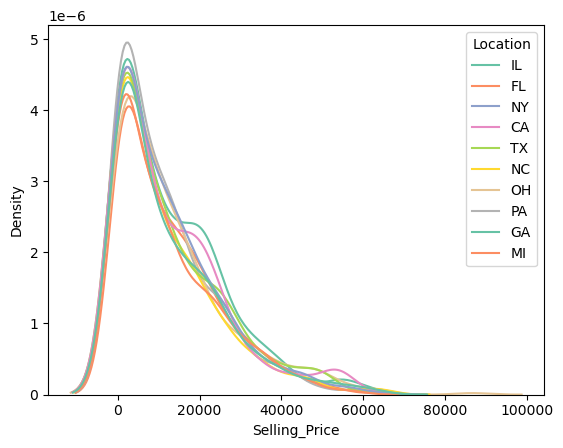

In [21]:
sns.kdeplot(x=df["Selling_Price"], hue=df["Location"], palette="Set2")
plt.show()

Yukardaki grafikte selling price negatife düştüğü için asağı cell de kontrol ettim fakat herhangi bir negatif değer bulamadım. Bu durum kde in veriyi düzgün bir eğriyle düzeltirken taşmasından dolayı olabileceğini düşünüyorum.

In [22]:
df[df["Selling_Price"]<0]

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price


In [23]:
X= df.drop("Selling_Price", axis=1)
y= df["Selling_Price"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=15, test_size=0.2)

In [25]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pre_processing= ColumnTransformer(
    transformers=[
        ("num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
         num_col
        ),
        ("cat",
             Pipeline([
                 ("imputer", SimpleImputer(strategy="most_frequent")),
                 ("encode", OneHotEncoder(drop="first"))
             ]),
         cat_col
        )
    ], remainder="passthrough"
)

In [26]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

poly_pipe= Pipeline([
    ("prepro", pre_processing),
    ("poly", PolynomialFeatures()),
    ("model", LinearRegression()) #2.derece
])

poly_pipe.fit(X_train, y_train)
poly_pred=poly_pipe.predict(X_test)

train_score= poly_pipe.score(X_train, y_train)
test_score= poly_pipe.score(X_test, y_test)

print("Mean Absolute Error:", (mean_absolute_error(y_test, poly_pred)))
print("Mean Squared Error:", (mean_squared_error(y_test, poly_pred)))
print("R2 Score:", (r2_score(y_test, poly_pred)))
print("Train Score:", train_score)
print("Test Score:", test_score)

Mean Absolute Error: 1398.803717752404
Mean Squared Error: 4106961.311897036
R2 Score: 0.9758834109535904
Train Score: 0.991728491036108
Test Score: 0.9758834109535904


In [28]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [56]:
model_dic= {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "Elasticnet" : ElasticNet(),
    "SVR" : SVR(),
    "KNN" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest" : RandomForestRegressor(),
    "AdaBoost" : AdaBoostRegressor(),
    "GradientBoost" : GradientBoostingRegressor(),
    "XGB" : XGBRegressor(),
    "LightGBM" : LGBMRegressor()
}

score_dic={}

In [57]:
for name, model in model_dic.items():
    model_pipe= Pipeline([
        ("pre_process", pre_processing),
        ("model", model)
    ])

    model_pipe.fit(X_train, y_train)
    y_pred= model_pipe.predict(X_test)

    train_score= model_pipe.score(X_train, y_train)
    test_score= model_pipe.score(X_test, y_test)

    r2_scores= r2_score(y_test, y_pred)

    score_dic[name]=r2_scores
    
    print(model)
    print("Mean Absolute Error:", (mean_absolute_error(y_test, y_pred)))
    print("Mean Squared Error:", (mean_squared_error(y_test, y_pred)))
    print("R2 Score:", (r2_score(y_test, y_pred)))
    print("Train Score:", train_score)
    print("Test Score:", test_score)
    print("----------------------------------\n")

LinearRegression()
Mean Absolute Error: 3802.730139976793
Mean Squared Error: 26597583.889739282
R2 Score: 0.8438156701310736
Train Score: 0.8489053189030632
Test Score: 0.8438156701310736
----------------------------------

Lasso()
Mean Absolute Error: 3803.3192645294457
Mean Squared Error: 26607330.204743836
R2 Score: 0.8437584385538
Train Score: 0.848887252428064
Test Score: 0.8437584385538
----------------------------------

Ridge()
Mean Absolute Error: 3801.360807431807
Mean Squared Error: 26600258.100294176
R2 Score: 0.8437999668331659
Train Score: 0.8488984535130274
Test Score: 0.8437999668331659
----------------------------------

ElasticNet()
Mean Absolute Error: 5122.75866037114
Mean Squared Error: 55955652.472905114
R2 Score: 0.6714214298528569
Train Score: 0.6848666622290234
Test Score: 0.6714214298528569
----------------------------------

SVR()
Mean Absolute Error: 9770.102084671127
Mean Squared Error: 185730555.60821554
R2 Score: -0.09063298697003819
Train Score: -0.0611

In [58]:
score_dic["Poly Regression"]=0.9758834109535904
score_dic

{'Linear Regression': 0.8438156701310736,
 'Lasso': 0.8437584385538,
 'Ridge': 0.8437999668331659,
 'Elasticnet': 0.6714214298528569,
 'SVR': -0.09063298697003819,
 'KNN': 0.8549581928333975,
 'Decision Tree': 0.9430772972661086,
 'Random Forest': 0.9683526487859065,
 'AdaBoost': 0.7100835777377157,
 'GradientBoost': 0.9569657117630528,
 'XGB': 0.9795598387718201,
 'LightGBM': 0.9786225990104833,
 'Poly Regression': 0.9758834109535904}

Parametre tunning yapmadan denenen model performanlarında en verimli modelin xgb olduğunu buldum ve bunun üstünde parametre tunning yaparak ilerledim. 2 puana yakın bir train test farkı olsa da bu net bir overfitting göstegesi değildir. Örneğin Decision Tree modelinde net bir overfitting görülebilir.

In [59]:
xgb_pipe= Pipeline([
    ("pre_proccess", pre_processing),
    ("model", XGBRegressor())
])

xgb_param= {
    "model__n_estimators" : [100, 300, 500],
    "model__learning_rate" : [0.01, 0.03, 0.05],
    "model__min_child_weight" : [3, 5],
    "model__subsample" : [1, 0.8],
    "model__colsample_bytree" : [0.8, 0.9, 1]
}

xgb_grid= GridSearchCV(estimator= xgb_pipe, param_grid=xgb_param, cv=5, n_jobs=-1, verbose=1, scoring="r2")

xgb_grid.fit(X_train, y_train)
xgb_pred= xgb_grid.predict(X_test)

train_score= xgb_grid.score(X_train, y_train)
test_score= xgb_grid.score(X_test, y_test)


print("Mean Absolute Error:", (mean_absolute_error(y_test, xgb_pred)))
print("Mean Squared Error:", (mean_squared_error(y_test, xgb_pred)))
print("R2 Score:", (r2_score(y_test, xgb_pred)))
print("Train Score:", train_score)
print("Test Score:", test_score)
print("----------------------------------\n")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mean Absolute Error: 1010.9003295898438
Mean Squared Error: 2877078.25
R2 Score: 0.9831054210662842
Train Score: 0.9972272515296936
Test Score: 0.9831054210662842
----------------------------------



In [60]:
score_dic["XGB ParamTunning"]=0.9831054210662842

In [61]:
xgb_grid.best_params_

{'model__colsample_bytree': 0.9,
 'model__learning_rate': 0.05,
 'model__min_child_weight': 3,
 'model__n_estimators': 500,
 'model__subsample': 0.8}

In [62]:
best_xgb= xgb_grid.best_estimator_

feature_name = best_xgb["pre_proccess"].get_feature_names_out()

importance= best_xgb["model"].feature_importances_

importance_df= pd.DataFrame({
    "Name" : feature_name,
    "Importance" : importance
}).sort_values(by="Importance", ascending=False)

In [63]:
importance_df

,Name,Importance
0,num__Year,0.108395
8,cat__Make_BMW,0.101150
13,cat__Make_Mercedes-Benz,0.093586
71,cat__Body_Type_Sedan,0.067428
44,cat__Model_Q7,0.064944
...,...,...
75,cat__Drivetrain_RWD,0.000327
78,cat__Location_IL,0.000316
59,cat__Transmission_Manual,0.000176
56,cat__Fuel_Type_Electric,0.000157


In [64]:
importance_df.head(10)

,Name,Importance
0,num__Year,0.108395
8,cat__Make_BMW,0.101150
13,cat__Make_Mercedes-Benz,0.093586
71,cat__Body_Type_Sedan,0.067428
44,cat__Model_Q7,0.064944
19,cat__Model_A6,0.061174
70,cat__Body_Type_SUV,0.037072
51,cat__Model_Tahoe,0.036404
12,cat__Make_Hyundai,0.031158
18,cat__Model_A4,0.025348


Modelimize etkisi olan en yüksek 10 feature sıraladım.

In [65]:
metric_df= pd.DataFrame(
    score_dic.items(),
    columns=["Model Name", "Score"]
)
metric_df

,Model Name,Score
0,Linear Regression,0.843816
1,Lasso,0.843758
2,Ridge,0.843800
3,Elasticnet,0.671421
4,SVR,-0.090633
5,KNN,0.854958
6,Decision Tree,0.943077
7,Random Forest,0.968353
8,AdaBoost,0.710084
9,GradientBoost,0.956966


In [66]:
metric_df.sort_values(by="Score", ascending=False)

,Model Name,Score
13,XGB ParamTunning,0.983105
10,XGB,0.979560
11,LightGBM,0.978623
12,Poly Regression,0.975883
7,Random Forest,0.968353
9,GradientBoost,0.956966
6,Decision Tree,0.943077
5,KNN,0.854958
0,Linear Regression,0.843816
2,Ridge,0.843800


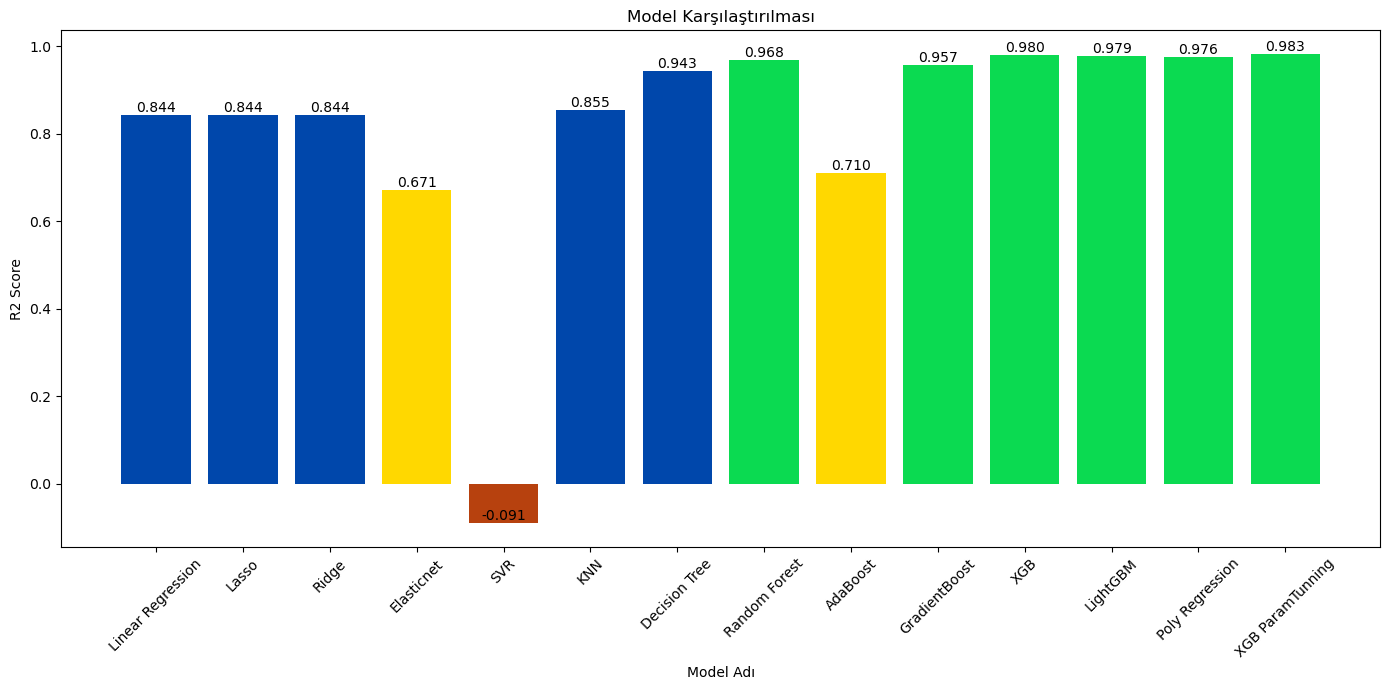

In [78]:
plt.figure(figsize=(14, 7))

renkler=["#0BDA51" if score > 0.95 
         else "#0047AB" if 0.95>= score > 0.8 
         else "#FFD800" if 0.8>= score > 0
         else "#B7410E"
         for score in metric_df["Score"]]

bars = plt.bar(
    metric_df["Model Name"],
    metric_df["Score"],
    color=renkler
)

for bar in bars:
    score= bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score,
        f"{score:.3f}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Model Adı")
plt.xticks(rotation=45)
plt.ylabel("R2 Score")
plt.title("Model Karşılaştırılması")


plt.tight_layout()
plt.show()

Grafikle görselleştirmenin daha rahat anlaşılabileceğini düşündüğüm için model başarılarına göre ayrı renklerle gruplandırarak daha anlaşılabilir bir performans grafiği ortaya çıkardım.

## 🔍 Sonuç ve Değerlendirme

Denenen 12 regresyon modeli arasında, hiperparametre optimizasyonu sonrası **XGBoost** en yüksek R² skorunu (**0.9831**) elde ederek en başarılı model olmuştur. Bunu Random Forest ve LightGBM gibi diğer ensemble/tree tabanlı modeller izlemiştir. Bu sonuç, veri setindeki doğrusal olmayan ilişkilerin, ensemble/tree tabanlı modeller tarafından doğrusal modellere (Linear Regression, Lasso, Ridge) kıyasla çok daha başarılı şekilde yakalandığını göstermektedir.

**Model Karşılaştırma Tablosu (R² Skorları):**

| Model | R² Skoru |
|---|---|
| XGBoost (tuning sonrası) | 0.9831 |
| LightGBM | 0.9786 |
| Polynomial Regression | 0.9759 |
| Gradient Boosting | 0.9570 |
| Random Forest | 0.9696 |
| KNN | 0.8550 |
| Linear Regression | 0.8438 |
| Ridge | 0.8438 |
| Lasso | 0.8438 |
| AdaBoost | 0.6887 |
| ElasticNet | 0.6714 |
| Decision Tree | 0.9318 |
| SVR | -0.0906 |

Bu proje; veri ön işleme, çoklu model karşılaştırması, hiperparametre optimizasyonu ve sonuçların iş bağlamında yorumlanması adımlarını uçtan uca kapsayan bir regresyon problemi çözümünü temsil etmektedir.